In [17]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [18]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

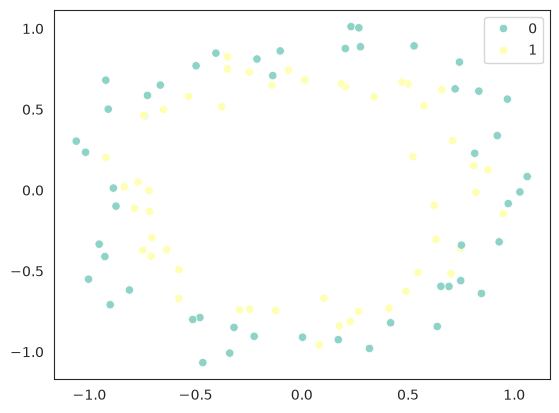

In [19]:
import matplotlib.pyplot as plt
sns.set_style('white')
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

plt.show()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [21]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/mnt/c/Users/vinay kumar/Desktop/Deep-Learning/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [23]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=400, verbose=0)

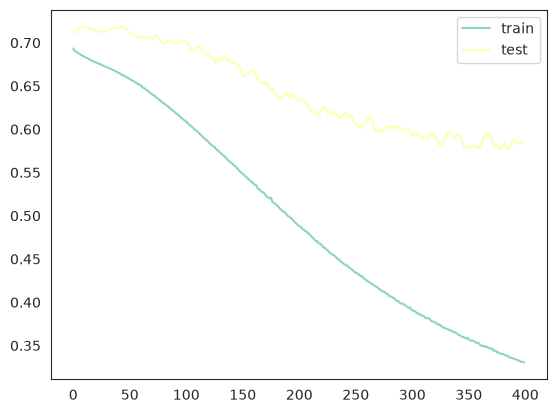

In [31]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [ ]:
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        return (self.model.predict(X, verbose=0) > 0.5).astype(int).ravel()

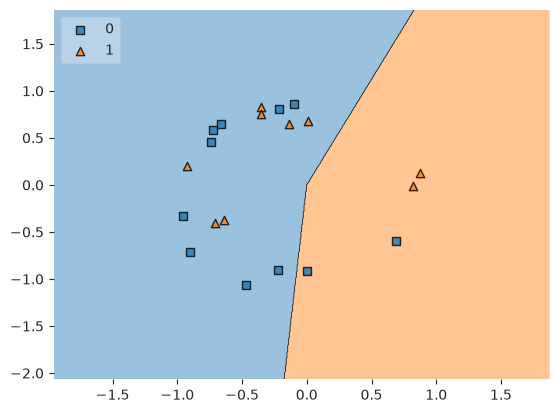

In [37]:
clf = KerasClassifierWrapper(model)

plot_decision_regions(
    X_test,
    y_test.ravel(),
    clf=clf,
    legend=2
)

plt.show()

In [59]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/mnt/c/Users/vinay kumar/Desktop/Deep-Learning/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=300,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [63]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6625 - loss: 0.6556 - val_accuracy: 0.5000 - val_loss: 0.7150
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6625 - loss: 0.6546 - val_accuracy: 0.5000 - val_loss: 0.7143
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6625 - loss: 0.6537 - val_accuracy: 0.5000 - val_loss: 0.7126
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6625 - loss: 0.6536 - val_accuracy: 0.5000 - val_loss: 0.7110
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7000 - loss: 0.6524 - val_accuracy: 0.5000 - val_loss: 0.7116
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6750 - loss: 0.6516 - val_accuracy: 0.5500 - val_loss: 0.7121
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6625 - loss: 0.6505 - val_accuracy: 0.5500 - val_loss: 0.7125
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6500 - loss: 0.6499 - val_accuracy: 0.5500 - v

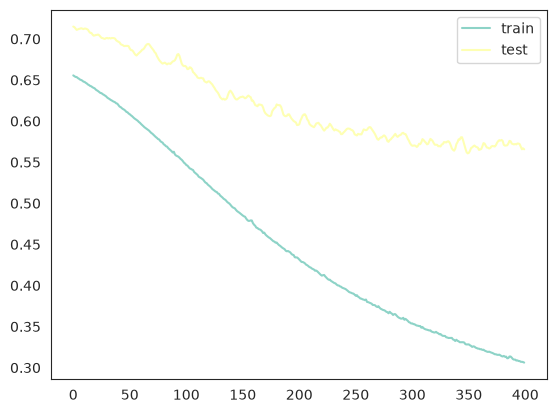

In [64]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

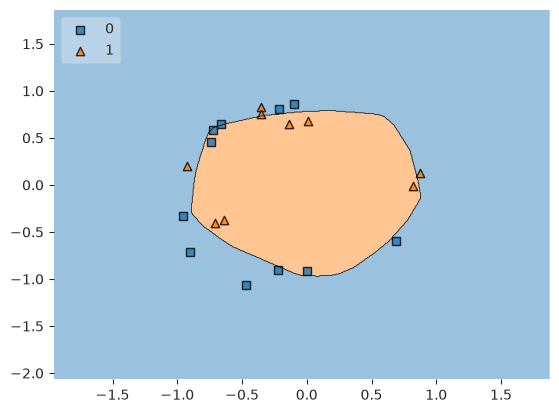

In [66]:
clf = KerasClassifierWrapper(model)

plot_decision_regions(
    X_test,
    y_test.ravel(),
    clf=clf,
    legend=2
)

plt.show()